In [80]:
from models import load_model_unet
from dataset import FlagOnGroundWithMask
import numpy as np
import matplotlib.pyplot as plt
import time
import cv2
import torch
from torchvision import transforms
import torch.nn.functional as F
from IPython.display import clear_output

WIDTH, HEIGHT = 1600, 1024

In [97]:
start_sec = 60

try:
    cap.release()
    cv2.destroyAllWindows()
except Exception:
    pass

# Load the UNet model
unet = load_model_unet("./checkpoints/unet.pth")
unet.eval()

vid_path = "/home/zeyadcode/Videos/RobEn/GX011072.MP4"
cap = cv2.VideoCapture(vid_path)

if not cap.isOpened():
    raise IOError("couldn't open capture")

fps = cap.get(cv2.CAP_PROP_FPS)
cap.set(cv2.CAP_PROP_POS_MSEC, start_sec * 1000)

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

preprocess = transforms.Compose([
    transforms.Lambda(lambda x:x / 255.0),
    transforms.Resize((256, 256)),  # Resize to 256x256
    transforms.Normalize(mean, std)
])

# 3) Create (resizable) windows
cv2.namedWindow("Frame", cv2.WINDOW_NORMAL)
cv2.namedWindow("Mask",  cv2.WINDOW_NORMAL)
# Optionally set initial size in pixels
cv2.resizeWindow("Frame",  800, 600)
cv2.resizeWindow("Mask",   800, 600)

# 4) Loop
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # BGR→RGB, HWC→CHW, uint8→float
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    t   = torch.from_numpy(rgb).permute(2,0,1).float()
    t   = preprocess(t).unsqueeze(0)

    # UNet inference
    with torch.no_grad():
        mask = unet(t)

    # Convert mask to displayable format (grayscale)
    mask_np = mask.squeeze(0).permute(1,2,0).cpu().numpy()
    mask_gray = (mask_np[...,0] * 255).astype(np.uint8)

    # Show
    cv2.imshow("Frame", frame)         # original BGR frame
    cv2.imshow("Mask",  mask_gray)     # single‑channel mask

    # Wait and check for 'q' to quit
    if cv2.waitKey(int(1000 / cap.get(cv2.CAP_PROP_FPS))) & 0xFF == ord('q'):
        break

Using cache found in /home/zeyadcode/.cache/torch/hub/mateuszbuda_brain-segmentation-pytorch_master


KeyboardInterrupt: 

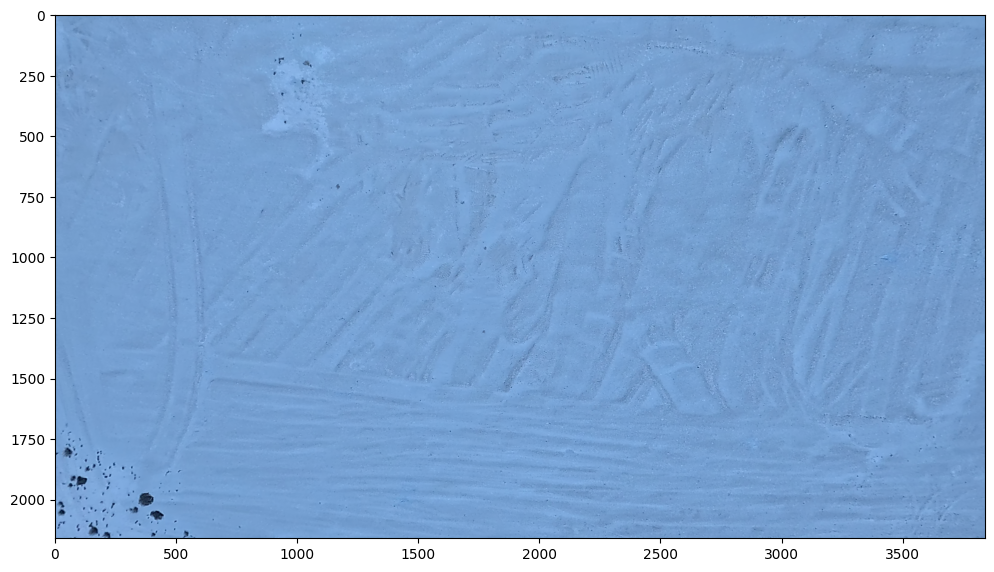

In [77]:
fps = cap.get(cv2.CAP_PROP_FPS)
target_time_sec = 81
frame_idx = int(target_time_sec * fps)

cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()

plt.figure(figsize=(12, 8), dpi=100)
plt.imshow(frame)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5618247..2.4233394].


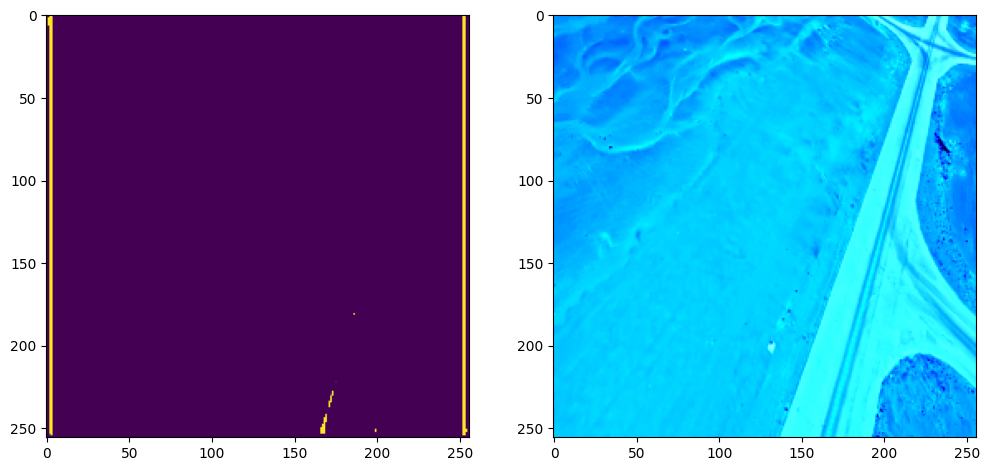

In [ ]:

frame_t /= 255
frame_t = to_tensor(frame_t)

mask = unet(frame_t)
mask_np = mask.squeeze(0).permute(1, 2, 0).detach().numpy()

frame_np = frame_t.squeeze(0).permute(1, 2, 0).detach().numpy()


plt.figure(figsize=(12, 8), dpi=100)

plt.subplot(1, 2, 1)
plt.imshow(mask_np)

plt.subplot(1, 2, 2)
plt.imshow(frame_np)